# Spectral fitting example (AGN)


This notebook fits NGC 4151 with the same binned 3ML workflow as the
original sub-method tutorial, but uses an independently constructed background
template.

The observed histogram is the DC4 mock data. The fitted background template is
the sum of:

1. the total DC4 instrumental and diffuse-background histogram selected with
   the NGC 4151 60° GTI, and
2. nuisance-source events read directly from their standalone `.fits.gz`
   files and binned after applying the same NGC 4151 GTI.

NGC 4151 is not included in the background template. It remains the only
response-folded source in the spectral model. The background template has one
free overall rate, while its energy and Compton-data-space shape remains fixed.


In [16]:
from cosipy import BinnedData
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.event_selection import GoodTimeInterval
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file

from cosipy.statistics import PoissonLikelihood
from cosipy.background_estimation import FreeNormBinnedBackground
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.response import BinnedThreeMLModelFolding, BinnedInstrumentResponse, BinnedThreeMLPointSourceResponse
from cosipy.data_io import EmCDSBinnedData

from histpy import Histogram

import sys

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.io import fits

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from threeML import PointSource, Model, JointLikelihood, DataList
from astromodels import Parameter, Cutoff_powerlaw, Powerlaw, Line

from pathlib import Path

%matplotlib inline


## Download and read in binned data


Define the mock-data, NGC 4151, total-background, standalone source,
orientation, response, and configuration paths. The total-background HDF5 file
is already selected with the NGC 4151 60° GTI. The nuisance sources are selected
from their full three-month FITS files below.


In [17]:
analysis_dir = Path.cwd()
if not (analysis_dir / "agn.yaml").exists():
    repo_notebook_dir = Path(
        "/Users/parshadkp/Software/cosipy/docs/tutorials/"
        "spectral_fits/continuum_fit/AGN"
    )
    if repo_notebook_dir.exists():
        analysis_dir = repo_notebook_dir

dc4_files_root = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    "COSI/Software_Files/DC4_Files"
)
source_event_root = dc4_files_root / "DC4_Sources"

binned_mock_data_file = (
    dc4_files_root
    / "Mock_Data/Mock_Data_Cut/"
    "mock_with_updated_NGC4151_FluxNTH_0p30_time_cut.hdf5"
)
NGC4151_file = Path(
    "/Users/parshadkp/Software/COSI_Data/DC4_Files/"
    "NGC_4151_ec200_0p30_DC4_COSI_cpl_pl_time_cut_in_fov.hdf5"
)
total_background_file = (
    dc4_files_root
    / "Background/"
    "Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_"
    "NGC4151_60deg_fov_cut.hdf5"
)
point_source_background_template_file = (
    dc4_files_root
    / "Background/"
    "Total_DC4_BG_plus_point_sources_3months_NGC4151_60deg_fov_cut_"
    "20sources.hdf5"
)
orientation_path = (
    dc4_files_root
    / "DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori"
)
response_path = (
    dc4_files_root
    / "ResponseContinuum.o3.e100_10000.b10log.s10396905069491."
    "m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"
)
agn_config = analysis_dir / "agn.yaml"

# Eight repeats of the three-month observation correspond to 24 months.
# Counts and orientation livetime are scaled together; source flux is unchanged.
exposure_multiplier = 1
exposure_months = exposure_multiplier * 3

include_nonthermal_tail = True
tail_ratio_at_200keV = 0.30
max_offaxis = 60 * u.deg
earth_occ = True

source_label = "NGC 4151"
source_l = 155.077404 * u.deg
source_b = 75.063170 * u.deg
source_coord = SkyCoord(l=source_l, b=source_b, frame="galactic")

for required_path in (
    binned_mock_data_file,
    NGC4151_file,
    total_background_file,
    orientation_path,
    response_path,
    agn_config,
):
    if not required_path.exists():
        raise FileNotFoundError(required_path)


In [18]:
# Continuum point-source files used to construct the nuisance template.
# NGC 4151 itself is deliberately excluded. Extended, diffuse, line-only, and
# GRB/MGF components are not added in this point-source-only version.
#
# The list is intentionally editable: remove a name to test the fit without it.
BACKGROUND_SOURCE_FILES = {
    "crab": source_event_root / "DC4/Crab_DC4_3months_unbinned_data_filtered_with_SAAcut.fits.gz",
    "four_c_21p35_flare": source_event_root / "DC3/4C21p35_flare_3months_unbinned_data_filtered_with_SAAcut.fits.gz",
    "maxi_j1820": source_event_root / "DC3/MAXIJ1820_3months_unbinned_data_filtered_with_SAAcut.fits.gz",
    "maxi_j1348": source_event_root / "DC3/MAXIJ1348_3months_unbinned_data_filtered_with_SAAcut.fits.gz",
    "four_c_71p07": source_event_root / "DC4/4C71p07_3months_unbinned_data_filtered_with_SAAcut.fits.gz",
    "four_c_21p35_noflare": source_event_root / "DC3/4C21p35_noflare_3months_unbinned_data_filtered_with_SAAcut.fits.gz",
    "cena": source_event_root / "DC4/CenA_3months_unbinned_data_filtered_with_SAAcut.fits.gz",
    "cyg_x1_hard": source_event_root / "DC3/cygX1_hard_3months_unbinned_data_filtered_with_SAAcut.fits.gz",
    "one_e_1740_compow": source_event_root / "DC3/1E1740_compow_3months_unbinned_data_filtered_with_SAAcut.fits.gz",
    "generic_magnetar": source_event_root / "DC4/magnetar2_3months_unbinned_data_filtered_with_SAAcut.fits.gz",
    "psr_b1259": source_event_root / "DC3/PSRB1259_3months_unbinned_data_filtered_with_SAAcut.fits.gz",
    "grs_1758_258": source_event_root / "DC3/GRS1758_3months_unbinned_data_filtered_with_SAAcut.fits.gz",
    "ls_5039": source_event_root / "DC3/LS5039_3months_unbinned_data_filtered_with_SAAcut.fits.gz",
    "one_rxs_j170849": source_event_root / "DC4/1RXSJ170849_3months_unbinned_data_filtered_with_SAAcut.fits.gz",
    "ngc1068": source_event_root / "DC4/NGC_1068_3months_unbinned_data_filtered_with_SAAcut.fits.gz",
    "cyg_x3": source_event_root / "DC4/cygX3_3months_unbinned_data_filtered_with_SAAcut.fits.gz",
    "psr_j1846": source_event_root / "DC3/PSRJ1846_3months_unbinned_data_filtered_with_SAAcut.fits.gz",
    # These point-source files have zero events in the current NGC 4151 GTI.
    # Keeping them in the table makes their lack of contribution explicit.
    "three_c_454p3_low": source_event_root / "DC4/3C454p3_low_3months_unbinned_data_filtered_with_SAAcut.fits.gz",
    "three_c_454p3_high": source_event_root / "DC4/3C454p3_high_3months_unbinned_data_filtered_with_SAAcut.fits.gz",
    "co_nova_continuum": source_event_root / "DC3/nova_co_continuum_3months_unbinned_data_filtered_with_SAAcut.fits.gz",
}

background_source_names = list(BACKGROUND_SOURCE_FILES)

unknown_source_names = sorted(
    set(background_source_names) - set(BACKGROUND_SOURCE_FILES)
)
if unknown_source_names:
    raise ValueError(f"Unknown background sources: {unknown_source_names}")

for source_name in background_source_names:
    source_path = BACKGROUND_SOURCE_FILES[source_name]
    if not source_path.exists():
        raise FileNotFoundError(source_path)

print(f"Configured point-source FITS files: {len(background_source_names)}")


Configured point-source FITS files: 20


Construct the NGC 4151 GTI from the 60° pointing cut with Earth occultation
enabled. The selected three-month history is then repeated by scaling interval
livetimes. This increases exposure without changing the injected source flux.


In [19]:
sc_orientation_full = SpacecraftHistory.open(orientation_path)
full_livetime = sc_orientation_full.cumulative_livetime().to_value(u.s)

source_gti = GoodTimeInterval.from_pointing_cut(
    source_coord,
    sc_orientation_full,
    max_offaxis,
    earth_occ=earth_occ,
)
sc_orientation_three_month = sc_orientation_full.apply_gti(source_gti)

sc_orientation = SpacecraftHistory(
    sc_orientation_three_month.obstime,
    sc_orientation_three_month.attitude,
    sc_orientation_three_month.location,
    livetime=sc_orientation_three_month.livetime * exposure_multiplier,
)
sc_orientation.cache_earth_occ = sc_orientation_three_month.cache_earth_occ

selected_livetime_three_month = (
    sc_orientation_three_month.cumulative_livetime().to_value(u.s)
)
selected_livetime = sc_orientation.cumulative_livetime().to_value(u.s)
orientation_label = f"{source_label} 60° GTI"
orientation_color = "red"

print(f"Full three-month orientation livetime: {full_livetime:,.1f} s")
print(
    "Selected three-month GTI livetime: "
    f"{selected_livetime_three_month:,.1f} s"
)
print(f"Scaled {exposure_months}-month livetime: {selected_livetime:,.1f} s")
print(
    "GTI/full three-month livetime fraction: "
    f"{selected_livetime_three_month / full_livetime:.4f}"
)


Full three-month orientation livetime: 6,579,555.0 s
Selected three-month GTI livetime: 980,415.0 s
Scaled 3-month livetime: 980,415.0 s
GTI/full three-month livetime fraction: 0.1490


Load the observed mock data, the NGC 4151-only histogram, and the independently
simulated total background. If the combined point-source template already
exists, load it directly without reading the standalone source FITS files or
overwriting the cache. Otherwise, select each point-source FITS file with the
same NGC 4151 GTI, bin it onto the analysis axes, add it to the total
background, and save the resulting unscaled three-month template once.


In [20]:
mock = Histogram.open(binned_mock_data_file).project("Em", "Phi", "PsiChi")
NGC4151 = Histogram.open(NGC4151_file).project("Em", "Phi", "PsiChi")
total_background_three_month = Histogram.open(total_background_file).project(
    "Em", "Phi", "PsiChi"
)

if mock.axes != NGC4151.axes:
    raise ValueError("Mock and NGC 4151 histograms do not have matching axes")
if mock.axes != total_background_three_month.axes:
    raise ValueError(
        "Mock and total-background histograms do not have matching axes"
    )


def events_in_gti(times, gti):
    """Vectorized GTI membership that also works for unsorted event times."""
    times = np.asarray(times, dtype=float)
    starts = np.asarray(gti.tstart_list.unix, dtype=float)
    stops = np.asarray(gti.tstop_list.unix, dtype=float)

    interval_index = np.searchsorted(starts, times, side="right") - 1
    valid = interval_index >= 0
    selected = np.zeros(times.size, dtype=bool)
    selected[valid] = times[valid] < stops[interval_index[valid]]
    return selected


def bin_source_fits_in_gti(event_path, gti, template_axes):
    """Bin one standalone source FITS file onto the analysis axes."""
    source_hist = Histogram(template_axes, sparse=True)

    with fits.open(event_path, memmap=False) as hdul:
        events = hdul[1].data
        selected = events_in_gti(events["TimeTags"], gti)
        n_gti_events = int(np.count_nonzero(selected))

        if n_gti_events:
            energies = np.asarray(events["Energies"][selected], dtype=float)
            phi = np.asarray(events["Phi"][selected], dtype=float)
            chi = np.asarray(
                events["Chi galactic"][selected],
                dtype=float,
            )
            psi = np.asarray(
                events["Psi galactic"][selected],
                dtype=float,
            )

    if n_gti_events:
        psichi = SkyCoord(
            l=chi * u.deg,
            b=psi * u.deg,
            frame="galactic",
        )
        source_hist.fill(
            energies * u.keV,
            np.rad2deg(phi) * u.deg,
            psichi,
        )

    n_analysis_events = int(
        source_hist.project("Em").to_dense(copy=False).contents.sum()
    )
    return source_hist, n_gti_events, n_analysis_events


if point_source_background_template_file.exists():
    # Reuse the previously generated aggregate template. This avoids rereading
    # every source FITS file and never overwrites an existing template.
    template_background_three_month = Histogram.open(
        point_source_background_template_file
    ).project("Em", "Phi", "PsiChi")
    if mock.axes != template_background_three_month.axes:
        raise ValueError(
            "Cached point-source background template axes do not match "
            "the mock-data axes"
        )

    source_background_three_month = (
        template_background_three_month - total_background_three_month
    )
    source_count_table = None
    print(
        "Loaded cached three-month point-source background template: "
        f"{point_source_background_template_file}"
    )
else:
    # HistPy does not support sparse += sparse reliably. The analysis
    # histogram has only 10 x 30 x 768 bins, so use a dense accumulator.
    source_background_three_month = Histogram(mock.axes, sparse=False)
    source_count_rows = []

    for source_name in background_source_names:
        source_path = BACKGROUND_SOURCE_FILES[source_name]
        source_hist, n_gti_events, n_analysis_events = (
            bin_source_fits_in_gti(
                source_path,
                source_gti,
                mock.axes,
            )
        )
        if n_analysis_events:
            source_background_three_month += source_hist

        source_count_rows.append(
            {
                "source": source_name,
                "GTI events": n_gti_events,
                "events in analysis bins": n_analysis_events,
                "included": n_analysis_events > 0,
            }
        )

    source_count_table = (
        pd.DataFrame(source_count_rows)
        .sort_values("events in analysis bins", ascending=False)
        .reset_index(drop=True)
    )

    template_background_three_month = (
        total_background_three_month.to_dense(copy=True)
    )
    template_background_three_month += source_background_three_month

    # Save only when the cache does not already exist.
    template_background_three_month.write(
        point_source_background_template_file
    )
    print(
        "Created three-month point-source background template: "
        f"{point_source_background_template_file}"
    )

# Scale observed counts and all template components consistently.
data_hist = mock * exposure_multiplier
ngc4151_hist = NGC4151 * exposure_multiplier
total_bkg = template_background_three_month * exposure_multiplier

# Diagnostic only: this is deliberately not used by the likelihood.
empirical_background_three_month = mock - NGC4151


def histogram_total(hist):
    return float(
        hist.project("Em").to_dense(copy=False).contents.sum()
    )


background_rate_initial = histogram_total(total_bkg) / selected_livetime


def make_background_distribution():
    # FreeNormBinnedBackground normalizes its input in place.
    total_bkg_for_fit = total_bkg.copy()
    total_bkg_for_fit += sys.float_info.min
    return {"total_bkg": total_bkg_for_fit}


print(
    "Initial combined-background rate: "
    f"{background_rate_initial:.4f} Hz"
)


Loaded cached three-month point-source background template: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/Background/Total_DC4_BG_plus_point_sources_3months_NGC4151_60deg_fov_cut_20sources.hdf5
Initial combined-background rate: 26.5048 Hz


### Point-source background-template diagnostics

The first table reports the standalone point-source FITS counts selected by the
NGC 4151 GTI. Sources with zero selected counts do not change the template. The
second table compares the independently assembled point-source-only template
with `mock - NGC4151`.

The residual is expected at this stage because extended, diffuse, line-only,
and transient GRB/MGF components have intentionally not been added.


Per-source count rows are not stored in the aggregate HDF5 cache. Delete the cached file to rebuild it and display that table.


,component,3-month GTI counts,3-month counts
0,Total DC4 background,"25,071,034.0","25,071,034.0"
1,Standalone nuisance sources,"914,718.0","914,718.0"
2,Combined fitted template,"25,985,752.0","25,985,752.0"
3,Mock minus NGC 4151 (diagnostic),"26,109,275.0","26,109,275.0"
4,Diagnostic residual,"123,523.0","123,523.0"


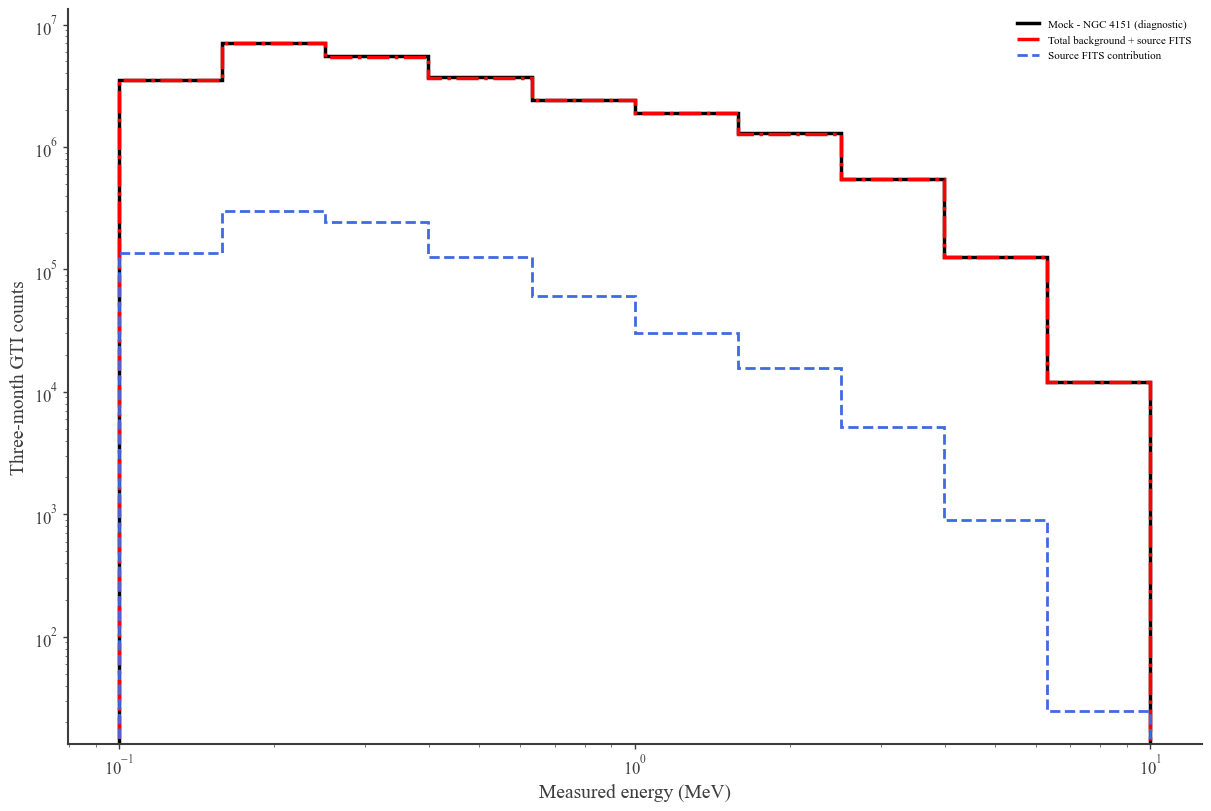

In [21]:
if source_count_table is not None:
    display(
        source_count_table.style.format(
            {
                "GTI events": "{:,.0f}",
                "events in analysis bins": "{:,.0f}",
            }
        )
    )
else:
    print(
        "Per-source count rows are not stored in the aggregate HDF5 cache. "
        "Delete the cached file to rebuild it and display that table."
    )

template_summary = pd.DataFrame(
    [
        {
            "component": "Total DC4 background",
            "3-month GTI counts": histogram_total(
                total_background_three_month
            ),
        },
        {
            "component": "Standalone nuisance sources",
            "3-month GTI counts": histogram_total(
                source_background_three_month
            ),
        },
        {
            "component": "Combined fitted template",
            "3-month GTI counts": histogram_total(
                template_background_three_month
            ),
        },
        {
            "component": "Mock minus NGC 4151 (diagnostic)",
            "3-month GTI counts": histogram_total(
                empirical_background_three_month
            ),
        },
        {
            "component": "Diagnostic residual",
            "3-month GTI counts": (
                histogram_total(empirical_background_three_month)
                - histogram_total(template_background_three_month)
            ),
        },
    ]
)
template_summary[f"{exposure_months}-month counts"] = (
    template_summary["3-month GTI counts"] * exposure_multiplier
)
display(
    template_summary.style.format(
        {
            "3-month GTI counts": "{:,.1f}",
            f"{exposure_months}-month counts": "{:,.1f}",
        }
    )
)

energy_edges_mev = mock.axes["Em"].edges.to_value(u.MeV)

fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.stairs(
    empirical_background_three_month.project("Em")
    .to_dense(copy=False)
    .contents,
    energy_edges_mev,
    color="black",
    linewidth=2.5,
    label="Mock - NGC 4151 (diagnostic)",
)
ax.stairs(
    template_background_three_month.project("Em")
    .to_dense(copy=False)
    .contents,
    energy_edges_mev,
    color="red",
    linestyle="dashdot",
    linewidth=2.5,
    label="Total background + source FITS",
)
ax.stairs(
    source_background_three_month.project("Em")
    .to_dense(copy=False)
    .contents,
    energy_edges_mev,
    color="royalblue",
    linestyle="dashed",
    linewidth=2.0,
    label="Source FITS contribution",
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Measured energy (MeV)")
ax.set_ylabel("Three-month GTI counts")
ax.legend(frameon=False)


Fetch and open the response.


In [22]:
# fetch_wasabi_file(
#     "COSI-SMEX/develop/Data/Responses/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5",
#     output=str(response_path),
#     checksum="7121f094be50e7bfe9b31e53015b0e85",
# )
dr = FullDetectorResponse.open(str(response_path))


## Perform spectral fit


Instantiate the COSI plugin with the independently assembled
total-background-plus-source template. The template shape is fixed, and its
single overall rate is initialized from its selected counts and livetime before
being fitted as a nuisance parameter.


In [23]:
def build_cosi_plugin(sc_orientation, plugin_name="cosi"):
    # Wrap the raw BinnedData object into the appropriate data interface.
    data = EmCDSBinnedData(data_hist)

    # Use the background model to initialize a background expectation interface.
    bkg = FreeNormBinnedBackground(make_background_distribution(),
                                   sc_history=sc_orientation,
                                   copy=False)

    # Wrap the raw response with the BinnedInstrumentResponse interface implementation.
    instrument_response = BinnedInstrumentResponse(dr, data)

    # Initialize the 3ML point-source response.
    psr = BinnedThreeMLPointSourceResponse(data=data,
                                           instrument_response=instrument_response,
                                           sc_history=sc_orientation,
                                           energy_axis=dr.axes["Ei"],
                                           polarization_axis=dr.axes["Pol"] if "Pol" in dr.axes.labels else None,
                                           nside=2 * data.axes["PsiChi"].nside)

    # Pass the 3ML point-source response to the interface implementation that performs the folding with the spectrum.
    response = BinnedThreeMLModelFolding(data=data, point_source_response=psr)

    # Likelihood to use.
    like_fun = PoissonLikelihood(data, response, bkg)

    # Initialize 3ML plugin.
    cosi = ThreeMLPluginInterface(plugin_name,
                                  like_fun,
                                  response,
                                  bkg)

    # Initialize background parameters, considered as nuisance parameters.
    for bkg_label in bkg.labels:
        cosi.bkg_parameter[bkg_label] = Parameter(bkg_label,
                                                  background_rate_initial,
                                                  min_value=0.0,
                                                  max_value=10000.0,
                                                  delta=0.05,
                                                  unit=u.Hz)

    return {
        "data": data,
        "bkg": bkg,
        "instrument_response": instrument_response,
        "psr": psr,
        "response": response,
        "cosi": cosi,
    }


Define NGC 4151 at the known location with a cutoff-power-law thermal component and an optional power-law tail in a single composite point-source model.


Build the plugin and model for the CPL+PL and CPL-only hypotheses, combine each with a JointLikelihood object, and perform the maximum likelihood fits.


In [24]:
K_inj = 0.15 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 200. * u.keV
index_inj = -1.75

spectrum_inj_ec200 = Cutoff_powerlaw()

spectrum_inj_ec200.K.value = K_inj.value
spectrum_inj_ec200.piv.value = piv_inj.value
spectrum_inj_ec200.xc.value = xc_inj.value
spectrum_inj_ec200.index.value = index_inj

spectrum_inj_ec200.K.unit = K_inj.unit
spectrum_inj_ec200.piv.unit = piv_inj.unit
spectrum_inj_ec200.xc.unit = xc_inj.unit

K_inj = tail_ratio_at_200keV * spectrum_inj_ec200.evaluate_at(200) / u.cm / u.cm / u.s / u.keV
piv_inj = 200. * u.keV
index_inj = -3.8

spectrum_inj_ec200_PL = Powerlaw()

spectrum_inj_ec200_PL.K.value = K_inj.value
spectrum_inj_ec200_PL.piv.value = piv_inj.value
spectrum_inj_ec200_PL.index.value = index_inj

spectrum_inj_ec200_PL.K.unit = K_inj.unit
spectrum_inj_ec200_PL.piv.unit = piv_inj.unit

spectrum_inj_ec200_total = spectrum_inj_ec200 + spectrum_inj_ec200_PL


In [25]:
def build_ngc4151_model(include_tail=None):
    if include_tail is None:
        include_tail = include_nonthermal_tail

    # Give it some harsher initial guesses.
    index = -1.75
    reference_piv = 1. * u.keV
    piv = 200. * u.keV
    K = (
        0.15
        * (piv / reference_piv).to_value(u.dimensionless_unscaled) ** index
    ) / u.cm / u.cm / u.s / u.keV
    xc = 200. * u.keV

    spectrum_cpl = Cutoff_powerlaw()

    spectrum_cpl.K.value = K.value
    spectrum_cpl.piv.value = piv.value
    spectrum_cpl.xc.value = xc.value
    spectrum_cpl.index.value = index
    spectrum_cpl.index.fix = True

    # Keep the hard bounds broad enough that covariance samples are not clipped.
    spectrum_cpl.K.min_value = 1e-8
    spectrum_cpl.K.max_value = 1e-2
    spectrum_cpl.xc.min_value = 100
    spectrum_cpl.xc.max_value = 50000

    spectrum_cpl.K.unit = K.unit
    spectrum_cpl.piv.unit = piv.unit
    spectrum_cpl.xc.unit = xc.unit

    spectral_shape = spectrum_cpl
    tail_link_ratio = None

    if include_tail:
        # Put the tail in the same point source as the thermal component.
        # This matches the injected model structure and avoids fitting two linked point sources at the same sky position.
        K_tail = tail_ratio_at_200keV * spectrum_cpl.evaluate_at(200) / u.cm / u.cm / u.s / u.keV
        piv_tail = 200. * u.keV
        index_tail = -3.8

        spectrum_tail = Powerlaw()
        spectrum_tail.K.value = K_tail.value
        spectrum_tail.piv.value = piv_tail.value
        spectrum_tail.index.value = index_tail

        spectrum_tail.K.min_value = 1e-12
        spectrum_tail.K.max_value = 10
        spectrum_tail.index.min_value = -5
        spectrum_tail.index.max_value = 2
        spectrum_tail.index.delta = 0.25

        spectrum_tail.K.unit = K_tail.unit
        spectrum_tail.piv.unit = piv_tail.unit

        tail_link_ratio = K_tail.value / spectrum_cpl.K.value

        spectral_shape = spectrum_cpl + spectrum_tail

    ngc4151 = PointSource("ngc4151",
                          l=source_l.to_value(u.deg),
                          b=source_b.to_value(u.deg),
                          spectral_shape=spectral_shape)

    model = Model(ngc4151)

    if include_tail:
        link_function = Line(a=0.0, b=tail_link_ratio)
        link_function.a.fix = True
        link_function.b.min_value = 0.0
        link_function.b.max_value = 1.0
        link_function.b.delta = max(abs(tail_link_ratio) * 0.1, 1e-8)
        model.link(
            model.ngc4151.spectrum.main.composite.K_2,
            model.ngc4151.spectrum.main.composite.K_1,
            link_function,
        )

    return model


In [26]:
def fit_ngc4151_hypothesis(label, plugin_name, include_tail, color, linestyle):
    print(f"\nFitting {label} ...")

    fit = {
        "label": label,
        "sc_orientation": sc_orientation,
        "include_nonthermal_tail": include_tail,
        "color": color,
        "linestyle": linestyle,
    }
    fit.update(build_cosi_plugin(sc_orientation, plugin_name=plugin_name))
    fit["model"] = build_ngc4151_model(include_tail=include_tail)
    fit["plugins"] = DataList(fit["cosi"])
    fit["like"] = JointLikelihood(fit["model"], fit["plugins"], verbose=False)

    _ = fit["like"].fit()
    fit["results"] = fit["like"].results
    fit["expectation"] = fit["response"].expectation()

    return fit


cpl_pl_fit = fit_ngc4151_hypothesis(
    f"{orientation_label} CPL + PL",
    plugin_name="cosi_cpl_pl",
    include_tail=True,
    color=orientation_color,
    linestyle="dashdot",
)
cpl_only_fit = fit_ngc4151_hypothesis(
    f"{orientation_label} CPL only",
    plugin_name="cosi_cpl_only",
    include_tail=False,
    color="black",
    linestyle="dashed",
)

primary_fit = cpl_pl_fit

data = primary_fit["data"]
bkg = primary_fit["bkg"]
response = primary_fit["response"]
cosi = primary_fit["cosi"]
like = primary_fit["like"]
results = primary_fit["results"]
expectation = primary_fit["expectation"]


Fitting NGC 4151 60° GTI CPL + PL ...


21:40:29 INFO      set the minimizer to minuit                                             ]8;id=386587;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=973464;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

21:40:42 WARNING   14.78 percent of samples have been thrown away because they failed the  ]8;id=536924;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=490235;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py#1645\1645]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

21:40:42 WARNING   The current value of the parameter K_1 (1.0) was above the new maximum 0.01.    ]8;id=51568;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=308024;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc_1 (10.0) was below the new minimum 100.0. ]8;id=586927;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=749379;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

...

1.00,-0.73,-0.47
-0.73,1.00,-0.02
-0.47,-0.02,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi_cpl_only,-118232125.63822828
total,-118232125.63822828


Values of statistical measures:

,statistical measures
AIC,-236464245.2763524
BIC,-236464214.23373994


## Non-thermal tail TS comparison


In [27]:
def get_likelihood_statistic(joint_likelihood):
    statistic_frame = joint_likelihood.results.get_statistic_frame()
    statistic_series = statistic_frame["-log(likelihood)"]

    if "total" in statistic_series.index:
        return float(statistic_series.loc["total"])

    return float(statistic_series.sum())


def model_improvement_ts(reference_likelihood, test_likelihood):
    return 2.0 * (
        get_likelihood_statistic(reference_likelihood)
        - get_likelihood_statistic(test_likelihood)
    )


stat_cpl = get_likelihood_statistic(cpl_only_fit["like"])
stat_cpl_pl = get_likelihood_statistic(cpl_pl_fit["like"])
TS_cpl_pl_vs_cpl = model_improvement_ts(cpl_only_fit["like"], cpl_pl_fit["like"])
tail_detection_sigma = np.sqrt(max(TS_cpl_pl_vs_cpl, 0.0))

tail_ts_comparison = pd.DataFrame(
    [
        {
            "spectrum": source_label,
            "fit": orientation_label,
            "minus_log_like_CPL": stat_cpl,
            "minus_log_like_CPL_plus_PL": stat_cpl_pl,
            "Delta_TS_CPL_plus_PL_vs_CPL": TS_cpl_pl_vs_cpl,
            "Sigma_added_PL": tail_detection_sigma,
        }
    ]
)

display(tail_ts_comparison)
print(
    "Added PL tail improvement TS: "
    f"{TS_cpl_pl_vs_cpl:.3f} ({tail_detection_sigma:.2f} sigma)"
)


,spectrum,fit,minus_log_like_CPL,minus_log_like_CPL_plus_PL,Delta_TS_CPL_plus_PL_vs_CPL,Sigma_added_PL
0,NGC 4151,NGC 4151 60° GTI,-1.182321e+08,-1.182321e+08,1.509519,1.228625


Added PL tail improvement TS: 1.510 (1.23 sigma)


## Error propagation and plotting


The summary of the results above gives the optimal values of the parameters, as well as the errors. Propagate the errors to the `evaluate_at` method of each fitted source spectrum.


In [28]:
results = primary_fit["results"]

print(f"\n{primary_fit['label']} fit results")
print(results.display())

source_parameters = {par.name: results.get_variates(par.path)
                     for par in results.optimized_model["ngc4151"].parameters.values()
                     if par.free}
primary_fit["flux_errors"] = results.propagate(
    results.optimized_model["ngc4151"].spectrum.main.shape.evaluate_at,
    **source_parameters,
)

print(results.optimized_model["ngc4151"])



NGC 4151 60° GTI CPL + PL fit results


Best fit values:

,result,unit
parameter,,
ngc4151.spectrum.main.composite.K_1,(6.1 -2.6 +4) x 10^-6,1 / (keV s cm2)
ngc4151.spectrum.main.composite.xc_1,(0.6 -0.4 +1.1) x 10^3,keV
ngc4151.spectrum.main.composite.K_2.Line.b,(1.5 +/- 1.4) x 10^-1,
ngc4151.spectrum.main.composite.index_2,-1.9 +/- 0.7,
total_bkg,(2.6630 +/- 0.0007) x 10,Hz


Correlation matrix:

1.00,-0.98,-0.87,0.95,-0.22
-0.98,1.00,0.79,-0.94,0.17
-0.87,0.79,1.00,-0.89,0.05
0.95,-0.94,-0.89,1.00,-0.14
-0.22,0.17,0.05,-0.14,1.00


...

         WARNING   The current value of the parameter K_1 (1.0) was above the new maximum 0.01.    ]8;id=732874;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=855502;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc_1 (10.0) was below the new minimum 100.0. ]8;id=471004;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=377701;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

         WARNING   The current value of the parameter K_1 (1.0) was above the new maximum 0.01.    ]8;id=946908;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=144141;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc_1 (10.0) was below the new minimum 100.0. ]8;id=226802;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=351833;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

  * ngc4151 (point source):
    * position:
      * l:
        * value: 155.077404
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: 75.06317
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * composite:
          * K_1:
            * value: 6.071963425635403e-06
            * desc: Normalization (differential flux at the pivot value)
            * min_value: 1.0e-08
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * piv_1:
            * value: 200.0
            * desc: Pivot value
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * index_1:
            * value: -1.75
        

Evaluate the flux and errors at a range of energies for the fitted and injected spectra.


In [29]:
energy = np.geomspace(200 * u.keV, 5 * u.MeV).to_value(u.keV)
flux_inj_thermal = np.zeros_like(energy)
flux_inj_tail = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux_inj_thermal[i] = spectrum_inj_ec200.evaluate_at(e)

    if include_nonthermal_tail:
        flux_inj_tail[i] = spectrum_inj_ec200_PL.evaluate_at(e)
        flux_inj[i] = spectrum_inj_ec200_total.evaluate_at(e)
    else:
        flux_inj[i] = flux_inj_thermal[i]

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = primary_fit["flux_errors"](e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)

fit_thermal_flux = np.zeros_like(energy)
fit_tail_flux = np.zeros_like(energy)

optimized_shape = results.optimized_model["ngc4151"].spectrum.main.shape
if primary_fit["include_nonthermal_tail"]:
    fit_thermal_shape, fit_tail_shape = optimized_shape.functions

    for i, e in enumerate(energy):
        fit_thermal_flux[i] = fit_thermal_shape.evaluate_at(e)
        fit_tail_flux[i] = fit_tail_shape.evaluate_at(e)
else:
    for i, e in enumerate(energy):
        fit_thermal_flux[i] = optimized_shape.evaluate_at(e)

primary_fit["flux_median"] = flux_median
primary_fit["flux_lo"] = flux_lo
primary_fit["flux_hi"] = flux_hi
primary_fit["fit_thermal_flux"] = fit_thermal_flux
primary_fit["fit_tail_flux"] = fit_tail_flux
primary_fit["injected_thermal_flux"] = flux_inj_thermal
primary_fit["injected_tail_flux"] = flux_inj_tail

binned_energy_edges = data_hist.axes["Em"].edges.value
binned_energy = 0.5 * (binned_energy_edges[1:] + binned_energy_edges[:-1])

data = primary_fit["data"]
bkg = primary_fit["bkg"]
response = primary_fit["response"]
expectation = primary_fit["expectation"]


21:40:56 WARNING   The current value of the parameter K_1 (1.0) was above the new maximum 0.01.    ]8;id=632046;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=619301;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc_1 (10.0) was below the new minimum 100.0. ]8;id=816095;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=69796;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

Plot the fitted and injected SEDs using the Paper_Plots component style. The injected curves show the thermal component, non-thermal tail, and total model; the fitted curves show the optimized total with its 68% interval and component best fits.


0.19903522339503518


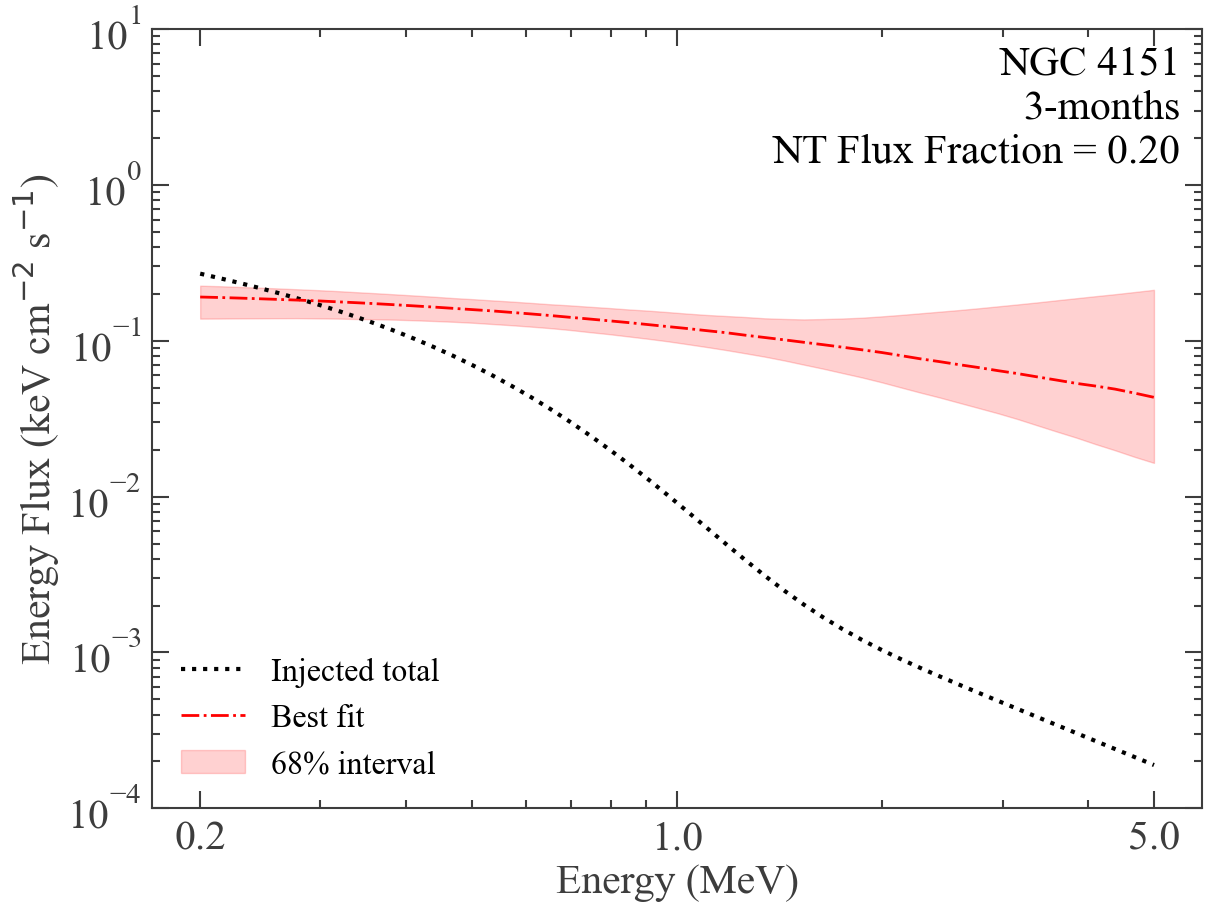

In [30]:
FONT_SIZE = 30
plt.rcParams["agg.path.chunksize"] = 10000
plt.rcParams.update({"font.size": FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams.update({
    "font.weight": "550",
    "axes.titleweight": "550",
    "axes.labelweight": "550",
})


def style_axis(ax):
    ax.xaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", top=True, pad=8, labelsize=FONT_SIZE)
    ax.xaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", top=True, pad=8)
    ax.yaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", right=True, pad=8, labelsize=FONT_SIZE)
    ax.yaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", right=True, pad=8)
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)


fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
style_axis(ax)

injected_label = "Injected total" if include_nonthermal_tail else "Injected thermal"
ax.plot(energy / 1000, energy * energy * flux_inj, color="black", ls=":", lw=3, label=injected_label)

ax.plot(
    energy / 1000,
    energy * energy * primary_fit["flux_median"],
    color=primary_fit["color"],
    lw=2,
    linestyle=primary_fit["linestyle"],
    label="Best fit",
)
ax.fill_between(
    energy / 1000,
    energy * energy * primary_fit["flux_lo"],
    energy * energy * primary_fit["flux_hi"],
    alpha=0.18,
    color=primary_fit["color"],
    label="68% interval",
)
ax.set_xscale("log")
ax.set_yscale("log")

ax.xaxis.set_major_locator(mticker.FixedLocator([0.2, 1.0, 5.0]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.2", "1.0", "5.0"]))

ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel(r"Energy Flux (keV cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)

ax.set_ylim(1e-4, 10)

def integrate_energy_flux(photon_flux):
    return np.trapezoid(energy * photon_flux, energy)

energy_flux_ratio = 0.0
if include_nonthermal_tail:
    thermal_flux = np.asarray([spectrum_inj_ec200.evaluate_at(e) for e in energy])
    tail_flux = np.asarray([spectrum_inj_ec200_PL.evaluate_at(e) for e in energy])
    thermal_energy_flux = integrate_energy_flux(thermal_flux)
    tail_energy_flux = integrate_energy_flux(tail_flux)
    energy_flux_ratio = tail_energy_flux / (tail_energy_flux + thermal_energy_flux)

ax.text(
    0.98,
    0.98,
    f"NGC 4151\n{exposure_months}-months\nNT Flux Fraction = {energy_flux_ratio:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=FONT_SIZE,
    fontweight="550",
)

_ = ax.legend(fontsize=23, loc="lower left", frameon=False)

print(energy_flux_ratio)
